In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# Percent matching
Way, Gregory P. et al. Morphology and gene expression profiling provide complementary information for mapping cell state

Cell Systems, Volume 13, Issue 11, 911 - 923.e9

For our percent matching metric, we performed a similar procedure as percent replicating (see above). The only differences were that we (1) used level 5 consensus signatures from both data sets and (2) considered MOA and dose information as replicates. We used level 5 consensus signatures instead of level 4 replicate signatures, because consensus signatures are less noisy and correct for potential different replicate cardinalities per compound within an MOA. We only considered MOAs that had three or more annotated compounds. This resulted in an analytical set of 127 unique MOAs. We considered compounds annotated with multiple MOAs as independent entities.


We only considered MOAs that had three or more annotated compounds. 
This resulted in an analytical set of 127 unique MOAs. 
We considered compounds annotated with multiple MOAs as independent entities.

# Get MOA annotation
Alt. get MESH classes 

In [4]:
annotations = pd.read_csv(parent_directory + '2022-05-13_MOA_Broad.csv')

annot_columns = ['pdid', 'EOS', 'Broad_MOA']
data_annotations_moa = annotations.loc[:, annot_columns]

data_annotations_moa['Broad_MOA'] = data_annotations_moa['Broad_MOA'].str.split(';')
data_annotations_moa_full = data_annotations_moa.explode('Broad_MOA', ignore_index=True)

value_counts_MOA = data_annotations_moa_full['Broad_MOA'].value_counts()
MOA_keep = value_counts_MOA[value_counts_MOA >= 3].index
annotations_moa_filtered = data_annotations_moa_full[data_annotations_moa_full['Broad_MOA'].isin(MOA_keep)]

annotations_moa_filtered = annotations_moa_filtered.rename(columns={'pdid': 'Metadata_pdid', 
                                    'EOS': 'Metadata_EOS', 
                                    'Broad_MOA': 'Metadata_Broad_MOA'
                                    })

# Load FMP U2OS data

Perform on median and filtered data

In [5]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_U2OS_type = '/*[0-9]_' + 'FMP_U2OS_norm_reduced_filtered_median.csv'
files_U2OS = glob.glob(input_path + file_U2OS_type)

### gets latest file
max_file_U2OS = max(files_U2OS, key=os.path.getctime)

### load file
data_U2OS = pd.read_csv(max_file_U2OS)
data_U2OS.shape

U2OS_annotated = pd.merge(annotations_moa_filtered, data_U2OS, on='Metadata_EOS', how='left')
U2OS_annotated.head()

U2OS_annotated_cleaned = U2OS_annotated.dropna()

In [6]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_U2OS_full_type = '/*[0-9]_' + 'FMP_U2OS_norm_median_full.csv'
files_U2OS_full = glob.glob(input_path + file_U2OS_full_type)

### gets latest file
max_file_U2OS_full = max(files_U2OS_full, key=os.path.getctime)

### load file
data_U2OS_full = pd.read_csv(max_file_U2OS_full)
data_U2OS_full.shape

(2467, 2982)

In [7]:
columns_after_reduction = data_U2OS_full.columns.intersection(data_U2OS.columns)
data_U2OS_full_reduced = data_U2OS_full[columns_after_reduction].copy()
data_U2OS_full_reduced.shape

(2467, 742)

In [8]:
# TODO: Merge in annotation colums
U2OS_full_annotated = pd.merge(annotations_moa_filtered, data_U2OS_full_reduced, on='Metadata_EOS', how='left')

In [9]:
U2OS_full_annotated_cleaned = U2OS_full_annotated.dropna()

# Test other function version

In [10]:
# Adjust functions from Cimini et al. 2023
# https://doi.org/10.1038/s41596-023-00840-9
# https://github.com/carpenter-singh-lab/2023_Cimini_NatureProtocols/blob/main/notebooks/utils.py

In [11]:
import numpy as np

def corr_between_compound_moa(df, metadata_moa, metadata_compound_name):
    """
        Correlation between compounds with the same MOA
        Parameters:
        -----------
        df: pd.DataFrame
        metadata_moa: MOA feature
        metadata_compound_name: Compound name feature
        Returns:
        --------
        list-like of correlation values
     """
    replicate_corr = []

    profile_df = (
        df[UTIL.get_metadata_vector(df)].assign(profiles=list(UTIL.get_featuredata(df).values))
    )

    replicate_grouped = (
        profile_df.groupby([metadata_moa, metadata_compound_name]).profiles.apply(list).reset_index()
    )

    moa_grouped = (
        replicate_grouped.groupby([metadata_moa]).profiles.apply(list).reset_index()
    )

    for i in range(len(moa_grouped)):
        if len(moa_grouped.iloc[i].profiles) > 1:
            compound1_profiles = moa_grouped.iloc[i].profiles[0]
            compound2_profiles = moa_grouped.iloc[i].profiles[1]

            corr = np.corrcoef(compound1_profiles, compound2_profiles)
            corr = corr[0:len(moa_grouped.iloc[i].profiles[0]), len(moa_grouped.iloc[i].profiles[0]):]
            # np.fill_diagonal(corr, np.nan)
            replicate_corr.append(np.nanmedian(corr))

    return replicate_corr

In [12]:
import random

def null_corr_between_compound_moa(df, n_samples, metadata_moa, metadata_compound_name):
    """
        Null distribution between random pairs of compounds.
        Parameters:
        ------------
        df: pandas.DataFrame
        n_samples: int
        metadata_moa: MOA feature
        metadata_compound_name: Compound name feature
        Returns:
        --------
        list-like of correlation values, with a  length of `n_samples`
    """
    df.reset_index(drop=True, inplace=True)
    null_corr = []

    profile_df = (
        df[UTIL.get_metadata_vector(df)].assign(profiles=list(UTIL.get_featuredata(df).values))
    )

    replicate_grouped = (
        profile_df.groupby([metadata_moa, metadata_compound_name]).profiles.apply(list).reset_index()
    )

    while len(null_corr) < n_samples:
        compounds = random.choices([_ for _ in range(len(replicate_grouped))], k=2)

        compound1_moa = replicate_grouped.iloc[compounds[0]][metadata_moa]
        compound2_moa = replicate_grouped.iloc[compounds[1]][metadata_moa]

        if compound1_moa != compound2_moa:

            compound1_profiles = replicate_grouped.iloc[compounds[0]].profiles
            compound2_profiles = replicate_grouped.iloc[compounds[1]].profiles
            corr = np.corrcoef(compound1_profiles, compound2_profiles)
            corr = corr[0:len(replicate_grouped.iloc[0].profiles), len(replicate_grouped.iloc[0].profiles):]
            # np.fill_diagonal(corr, np.nan)
            null_corr.append(np.nanmedian(corr))  # median replicate correlation
            
    return null_corr

In [13]:
def percent_matching_test(Data, n_samples = 100, MOA_col = 'Metadata_Broad_MOA', ID_col = 'Metadata_EOS',  description = "Data"):

    corr_replicating_df = pd.DataFrame()

    replicating_corr = list(corr_between_compound_moa(Data, MOA_col, ID_col))
    null_replicating = list(null_corr_between_compound_moa(Data, n_samples, MOA_col, ID_col))
    
    prop_95_matching, value_95_matching, value_5_matching = UTIL.percent_score(null_replicating, replicating_corr, how='both')

    above_threshold = replicating_corr > value_95_matching
    prop_95_matching = np.mean(above_threshold.astype(float))*100

    below_perc_5 = replicating_corr < value_5_matching
    prop_5_matching = np.mean(below_perc_5.astype(float))*100

    corr_replicating_df = corr_replicating_df.append({'Description': description,
                                                        'Matching':replicating_corr,
                                                        'Null_Matching':null_replicating,
                                                        'Percent_Matching_above_95':'%.1f'%prop_95_matching,
                                                        'Percent_Matching_below_5':'%.1f'%prop_5_matching,
                                                        'Value_95':value_95_matching,
                                                        'Value_5':value_5_matching},
                                                        ignore_index=True)
    
    return corr_replicating_df

In [14]:
corr_replicating_df = percent_matching_test(U2OS_annotated_cleaned, 10000, 'Metadata_Broad_MOA', 'Metadata_EOS')

<ipython-input-13-58f8deb7b6fd>:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


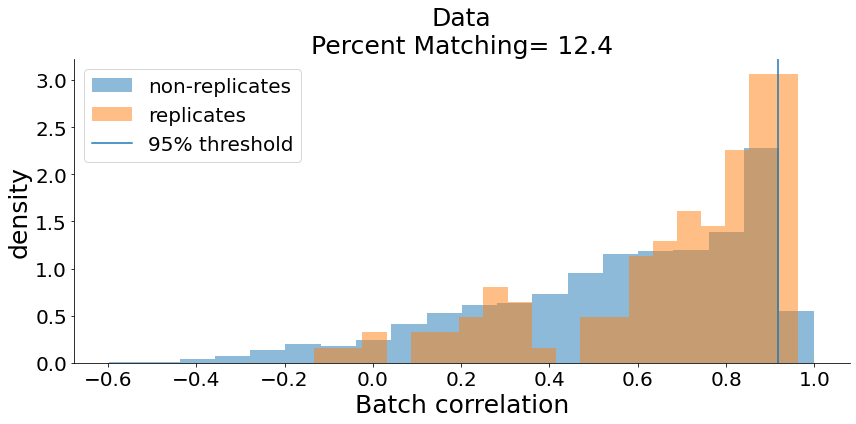

In [15]:
corr_replicating_df = corr_replicating_df

n_experiments = len(corr_replicating_df)


plt.rcParams['figure.facecolor'] = 'white' # Enabling this makes the figure axes and labels visible in PyCharm Dracula theme
plt.figure(figsize=[12, n_experiments*6])

for i in range(n_experiments):
    plt.subplot(n_experiments, 1, i+1)
    plt.hist(corr_replicating_df.loc[i,'Null_Matching'], label='non-replicates', density=True, bins=20, alpha=0.5)
    plt.hist(corr_replicating_df.loc[i,'Matching'], label='replicates', density=True, bins=20, alpha=0.5)
    plt.axvline(corr_replicating_df.loc[i,'Value_95'], label='95% threshold')
    plt.legend(fontsize=20)
    plt.title(
        f"{corr_replicating_df.loc[i,'Description']}\n" +
        f"Percent Matching= {corr_replicating_df.loc[i,'Percent_Matching_above_95']}",
        fontsize=25
    )
    plt.ylabel("density", fontsize=25)
    plt.xlabel("Batch correlation", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    sns.despine()
plt.tight_layout()

plt.savefig(figure_path + str(date.today()) + "_FMP_U2OS_Percent_Matching.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)

# Test with HepG2 data

In [16]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_FMP_HepG2_type = '/*[0-9]_' + 'FMP_HepG2_norm_reduced_filtered_median.csv'
files_FMP_HepG2 = glob.glob(input_path + file_FMP_HepG2_type)

### gets latest file
max_file_FMP_HepG2 = max(files_FMP_HepG2, key=os.path.getctime)

### load file
data_FMP_HepG2 = pd.read_csv(max_file_FMP_HepG2)
data_FMP_HepG2.shape

FMP_HepG2_annotated = pd.merge(annotations_moa_filtered, data_FMP_HepG2, on='Metadata_EOS', how='left')
FMP_HepG2_annotated.head()

FMP_HepG2_annotated_cleaned = FMP_HepG2_annotated.dropna()

In [17]:
corr_replicating_df = percent_matching_test(FMP_HepG2_annotated_cleaned, 10000, 'Metadata_Broad_MOA', 'Metadata_EOS')

<ipython-input-13-58f8deb7b6fd>:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


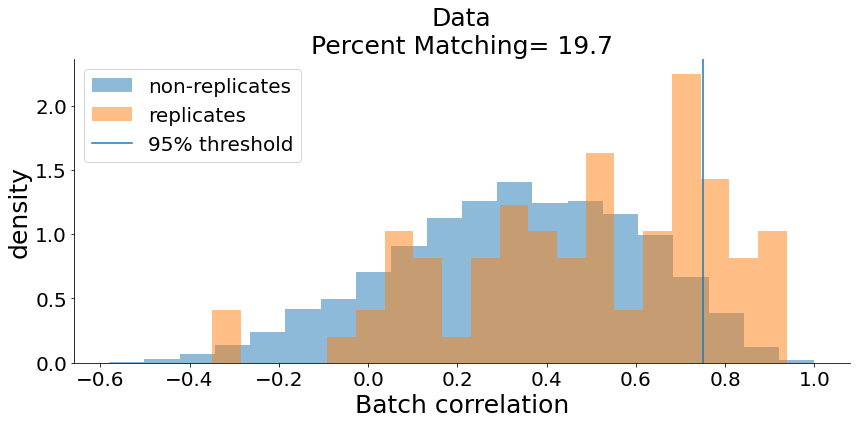

In [18]:
corr_replicating_df = corr_replicating_df

n_experiments = len(corr_replicating_df)


plt.rcParams['figure.facecolor'] = 'white' # Enabling this makes the figure axes and labels visible in PyCharm Dracula theme
plt.figure(figsize=[12, n_experiments*6])

for i in range(n_experiments):
    plt.subplot(n_experiments, 1, i+1)
    plt.hist(corr_replicating_df.loc[i,'Null_Matching'], label='non-replicates', density=True, bins=20, alpha=0.5)
    plt.hist(corr_replicating_df.loc[i,'Matching'], label='replicates', density=True, bins=20, alpha=0.5)
    plt.axvline(corr_replicating_df.loc[i,'Value_95'], label='95% threshold')
    plt.legend(fontsize=20)
    plt.title(
        f"{corr_replicating_df.loc[i,'Description']}\n" +
        f"Percent Matching= {corr_replicating_df.loc[i,'Percent_Matching_above_95']}",
        fontsize=25
    )
    plt.ylabel("density", fontsize=25)
    plt.xlabel("Batch correlation", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    sns.despine()
plt.tight_layout()

plt.savefig(figure_path + str(date.today()) + "_FMP_HepG2_Percent_Matching.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)

# IMTM data

In [19]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_IMTM_HepG2_type = '/*[0-9]_' + 'IMTM_HepG2_norm_reduced_filtered_median.csv'
files_IMTM_HepG2 = glob.glob(input_path + file_IMTM_HepG2_type)

### gets latest file
max_file_IMTM_HepG2 = max(files_IMTM_HepG2, key=os.path.getctime)

### load file
data_IMTM_HepG2 = pd.read_csv(max_file_IMTM_HepG2)
data_IMTM_HepG2.shape

IMTM_HepG2_annotated = pd.merge(annotations_moa_filtered, data_IMTM_HepG2, on='Metadata_EOS', how='left')
IMTM_HepG2_annotated.head()

IMTM_HepG2_annotated_cleaned = IMTM_HepG2_annotated.dropna()

In [20]:
corr_replicating_df = percent_matching_test(IMTM_HepG2_annotated_cleaned, 10000, 'Metadata_Broad_MOA', 'Metadata_EOS')

<ipython-input-13-58f8deb7b6fd>:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


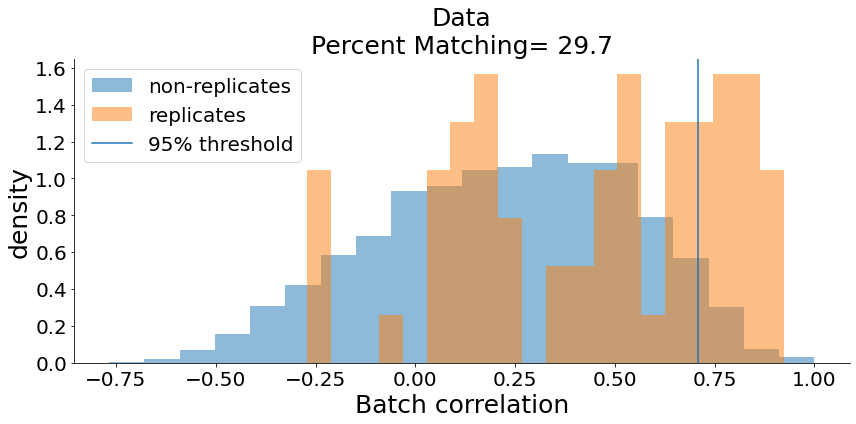

In [21]:
corr_replicating_df = corr_replicating_df

n_experiments = len(corr_replicating_df)


plt.rcParams['figure.facecolor'] = 'white' # Enabling this makes the figure axes and labels visible in PyCharm Dracula theme
plt.figure(figsize=[12, n_experiments*6])

for i in range(n_experiments):
    plt.subplot(n_experiments, 1, i+1)
    plt.hist(corr_replicating_df.loc[i,'Null_Matching'], label='non-replicates', density=True, bins=20, alpha=0.5)
    plt.hist(corr_replicating_df.loc[i,'Matching'], label='replicates', density=True, bins=20, alpha=0.5)
    plt.axvline(corr_replicating_df.loc[i,'Value_95'], label='95% threshold')
    plt.legend(fontsize=20)
    plt.title(
        f"{corr_replicating_df.loc[i,'Description']}\n" +
        f"Percent Matching= {corr_replicating_df.loc[i,'Percent_Matching_above_95']}",
        fontsize=25
    )
    plt.ylabel("density", fontsize=25)
    plt.xlabel("Batch correlation", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    sns.despine()
plt.tight_layout()

plt.savefig(figure_path + str(date.today()) + "_IMTM_HepG2_Percent_Matching.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)

# MEDINA Data

In [22]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_MEDINA_HepG2_type = '/*[0-9]_' + 'MEDINA_HepG2_norm_reduced_filtered_median.csv'
files_MEDINA_HepG2 = glob.glob(input_path + file_MEDINA_HepG2_type)

### gets latest file
max_file_MEDINA_HepG2 = max(files_MEDINA_HepG2, key=os.path.getctime)

### load file
data_MEDINA_HepG2 = pd.read_csv(max_file_MEDINA_HepG2)
data_MEDINA_HepG2.shape

MEDINA_HepG2_annotated = pd.merge(annotations_moa_filtered, data_MEDINA_HepG2, on='Metadata_EOS', how='left')
MEDINA_HepG2_annotated.head()

MEDINA_HepG2_annotated_cleaned = MEDINA_HepG2_annotated.dropna()

In [23]:
corr_replicating_df = percent_matching_test(MEDINA_HepG2_annotated_cleaned , 10000, 'Metadata_Broad_MOA', 'Metadata_EOS')

<ipython-input-13-58f8deb7b6fd>:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


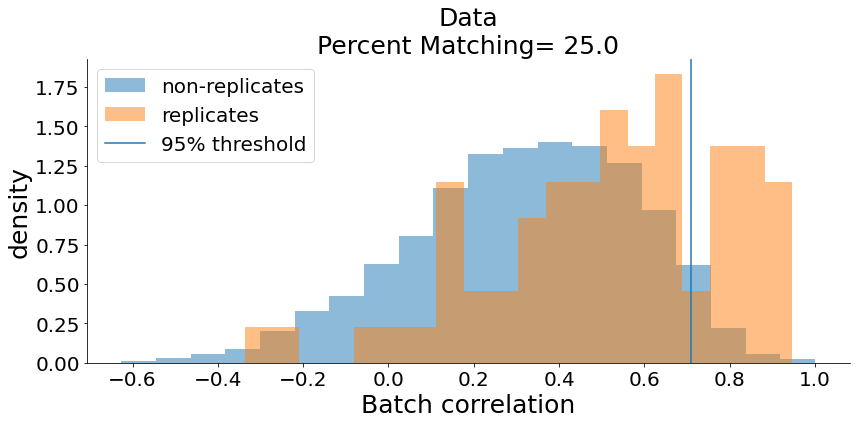

In [24]:
corr_replicating_df = corr_replicating_df

n_experiments = len(corr_replicating_df)


plt.rcParams['figure.facecolor'] = 'white' # Enabling this makes the figure axes and labels visible in PyCharm Dracula theme
plt.figure(figsize=[12, n_experiments*6])

for i in range(n_experiments):
    plt.subplot(n_experiments, 1, i+1)
    plt.hist(corr_replicating_df.loc[i,'Null_Matching'], label='non-replicates', density=True, bins=20, alpha=0.5)
    plt.hist(corr_replicating_df.loc[i,'Matching'], label='replicates', density=True, bins=20, alpha=0.5)
    plt.axvline(corr_replicating_df.loc[i,'Value_95'], label='95% threshold')
    plt.legend(fontsize=20)
    plt.title(
        f"{corr_replicating_df.loc[i,'Description']}\n" +
        f"Percent Matching= {corr_replicating_df.loc[i,'Percent_Matching_above_95']}",
        fontsize=25
    )
    plt.ylabel("density", fontsize=25)
    plt.xlabel("Batch correlation", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    sns.despine()
plt.tight_layout()

plt.savefig(figure_path + str(date.today()) + "_MEDINA_HepG2_Percent_Matching.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)

# USC Data

In [25]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_USC_HepG2_type = '/*[0-9]_' + 'USC_HepG2_norm_reduced_filtered_median.csv'
files_USC_HepG2 = glob.glob(input_path + file_USC_HepG2_type)

### gets latest file
max_file_USC_HepG2 = max(files_USC_HepG2, key=os.path.getctime)

### load file
data_USC_HepG2 = pd.read_csv(max_file_USC_HepG2)
data_USC_HepG2.shape

USC_HepG2_annotated = pd.merge(annotations_moa_filtered, data_USC_HepG2, on='Metadata_EOS', how='left')
USC_HepG2_annotated.head()

USC_HepG2_annotated_cleaned = USC_HepG2_annotated.dropna()

In [26]:
corr_replicating_df = percent_matching_test(USC_HepG2_annotated_cleaned , 10000, 'Metadata_Broad_MOA', 'Metadata_EOS')

<ipython-input-13-58f8deb7b6fd>:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


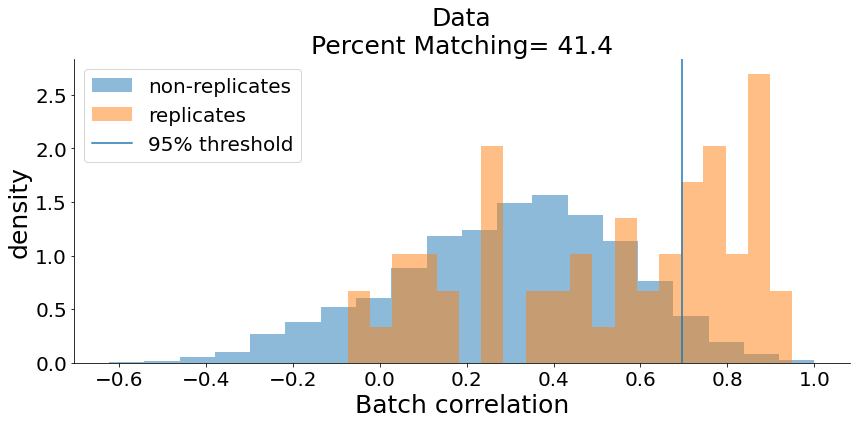

In [27]:
corr_replicating_df = corr_replicating_df

n_experiments = len(corr_replicating_df)


plt.rcParams['figure.facecolor'] = 'white' # Enabling this makes the figure axes and labels visible in PyCharm Dracula theme
plt.figure(figsize=[12, n_experiments*6])

for i in range(n_experiments):
    plt.subplot(n_experiments, 1, i+1)
    plt.hist(corr_replicating_df.loc[i,'Null_Matching'], label='non-replicates', density=True, bins=20, alpha=0.5)
    plt.hist(corr_replicating_df.loc[i,'Matching'], label='replicates', density=True, bins=20, alpha=0.5)
    plt.axvline(corr_replicating_df.loc[i,'Value_95'], label='95% threshold')
    plt.legend(fontsize=20)
    plt.title(
        f"{corr_replicating_df.loc[i,'Description']}\n" +
        f"Percent Matching= {corr_replicating_df.loc[i,'Percent_Matching_above_95']}",
        fontsize=25
    )
    plt.ylabel("density", fontsize=25)
    plt.xlabel("Batch correlation", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    sns.despine()
plt.tight_layout()

plt.savefig(figure_path + str(date.today()) + "_USC_HepG2_Percent_Matching.pdf", 
            transparent=False, 
            bbox_inches='tight', 
            dpi = 600)